# Evaluation of uncertainty of models on 60km -> 2.2km-4x over Birmingham

In [ ]:
%reload_ext autoreload

%autoreload 2

%reload_ext dotenv
%dotenv

In [ ]:
from mlde_analysis.default_params import *

In [ ]:
# Parameters
desc = "Comparison of diffusion model for CPMGEM-pr paper\nTest split\n12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set\nCompare techniques: diffusion, u-net, bilinear\n"
eval_vars = ["pr"]
derived_variables_config = {}
dataset_configs = {
    "CPM": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
    "GCM": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
}
split = "test"
ensemble_members = [
    "01",
    "04",
    "05",
    "06",
    "07",
    "08",
    "09",
    "10",
    "11",
    "12",
    "13",
    "15",
]
samples_per_run = 6
sample_configs = {
    "CPM": [
        {
            "label": "CPMGEM_cCPM",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "color": "tab:blue",
            "order": 11,
        },
        {
            "label": "U-Net_cCPM",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/deterministic/ukcp_local_pr_12em_plain_unet/bham_pSTV-ema-gradcl-256-batch",
                    "checkpoint": "epoch_100",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": True,
            "color": "tab:orange",
            "order": 2,
        },
        {
            "label": "BCSD_cCPM",
            "sample_specs": [
                {
                    "fq_model_id": "bcsd-v1/ukcp_local_pr_12em-ws3",
                    "checkpoint": "epoch-0",
                    "input_xfm": "bham64_ccpm-4x_12em_linpr_pr-bcsd",
                    "dataset": "bham64_ccpm-4x_12em_linpr_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": True,
            "color": "tab:red",
            "order": 1,
            "UQ": True,
            "CCS": True,
        },
    ],
    "GCM": [
        {
            "label": "CPMGEM_GCM",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "input_xfm": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-pixelmmsstan",
                    "dataset": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "UQ": False,
            "color": "tab:green",
            "order": 20,
        }
    ],
}
sample_configs_at_60km = [
    {
        "label": "CPMGEM_GCM@60km",
        "sample_specs": [
            {
                "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV/postprocess/gcm-grid",
                "checkpoint": "epoch_20",
                "input_xfm": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-pixelmmsstan",
                "dataset": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                "variables": ["pr"],
            }
        ],
        "deterministic": False,
    }
]
dataset_configs_at_60km = {
    "CPM": "bham64_ccpm-60km_12em_pr_pr",
    "GCM": "bham64_gcm-60km_12em_rawpr_pr",
}
example_percentiles = {
    "CPM": {
        "DJF Wet": {"percentile": 0.8, "variable": "pr", "season": "DJF"},
        "DJF Wettest": {"percentile": 1, "variable": "pr", "season": "DJF"},
        "JJA Wet": {"percentile": 0.8, "variable": "pr", "season": "JJA"},
        "JJA Wettest": {"percentile": 1, "variable": "pr", "season": "JJA"},
    },
    "GCM": {
        "DJF Wet": {"percentile": 0.8, "variable": "pr", "season": "DJF"},
        "DJF Wettest": {"percentile": 1, "variable": "pr", "season": "DJF"},
        "JJA Wet": {"percentile": 0.8, "variable": "pr", "season": "JJA"},
        "JJA Wettest": {"percentile": 1, "variable": "pr", "season": "JJA"},
    },
}
example_overrides = {"CPM": {"JJA Wet": ["01", "1993-08-01 12:00:00"]}, "GCM": {}}
examples_sample_idxs = [2, 5]
niterations = 30
bootstrap_configs = {"niterations": {"spread-error": 50}}


In [ ]:
import functools
import math
import string

import IPython
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from properscoring import crps_ensemble
import xarray as xr
from xhistogram.xarray import histogram

from mlde_analysis.bootstrap import resample_examples
from mlde_analysis.data import prep_eval_data
from mlde_analysis.display import pretty_table
from mlde_analysis.uncertainty import plot_spread_error, plot_scatter, compute_rmss_rmse_bins, se_bins, serat
from mlde_analysis.utils import chained_groupby_map

In [ ]:
matplotlib.rcParams['figure.dpi'] = 300

In [ ]:
IPython.display.Markdown(desc)

Comparison of diffusion model for CPMGEM-pr paper
Test split
12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set
Compare techniques: diffusion, u-net, bilinear


In [ ]:
%reload_ext mlde_analysis.magics 
EVAL_DS, MODELS, CPM_DAS, PRED_DAS, VAR_DAS, MODELLABEL2SPEC = %load_eval_data
EVAL_DS

{'CPM': <xarray.Dataset> Size: 34GB
 Dimensions:                     (model: 3, sample_id: 6, ensemble_member: 12,
                                  time: 3240, grid_latitude: 64,
                                  grid_longitude: 64, bnds: 2)
 Coordinates:
   * ensemble_member             (ensemble_member) <U2 96B '01' '04' ... '15'
   * time                        (time) object 26kB 1981-03-01 12:00:00 ... 20...
     season                      (time) int64 26kB 1 1 1 1 1 1 1 ... 2 2 2 2 2 2
   * grid_latitude               (grid_latitude) float32 256B -2.49 ... 2.55
   * grid_longitude              (grid_longitude) float32 256B 357.9 ... 363.0
     time_period                 (time) <U8 104kB 'historic' ... 'future'
   * model                       (model) object 24B 'CPMGEM_cCPM' ... 'BCSD_cCPM'
     dec_adjusted_year           (time) int64 26kB 1981 1981 1981 ... 2076 2076
     stratum                     (time) <U12 156kB 'historic MAM' ... 'future ...
     tp_season_year         

## Figure: spread-error

* Spread-error
  * https://journals.ametsoc.org/view/journals/hydr/15/4/jhm-d-14-0008_1.xml?tab_body=fulltext-display
  * https://journals.ametsoc.org/view/journals/aies/2/2/AIES-D-22-0061.1.xml
  * https://www.sciencedirect.com/science/article/pii/S0021999107000812

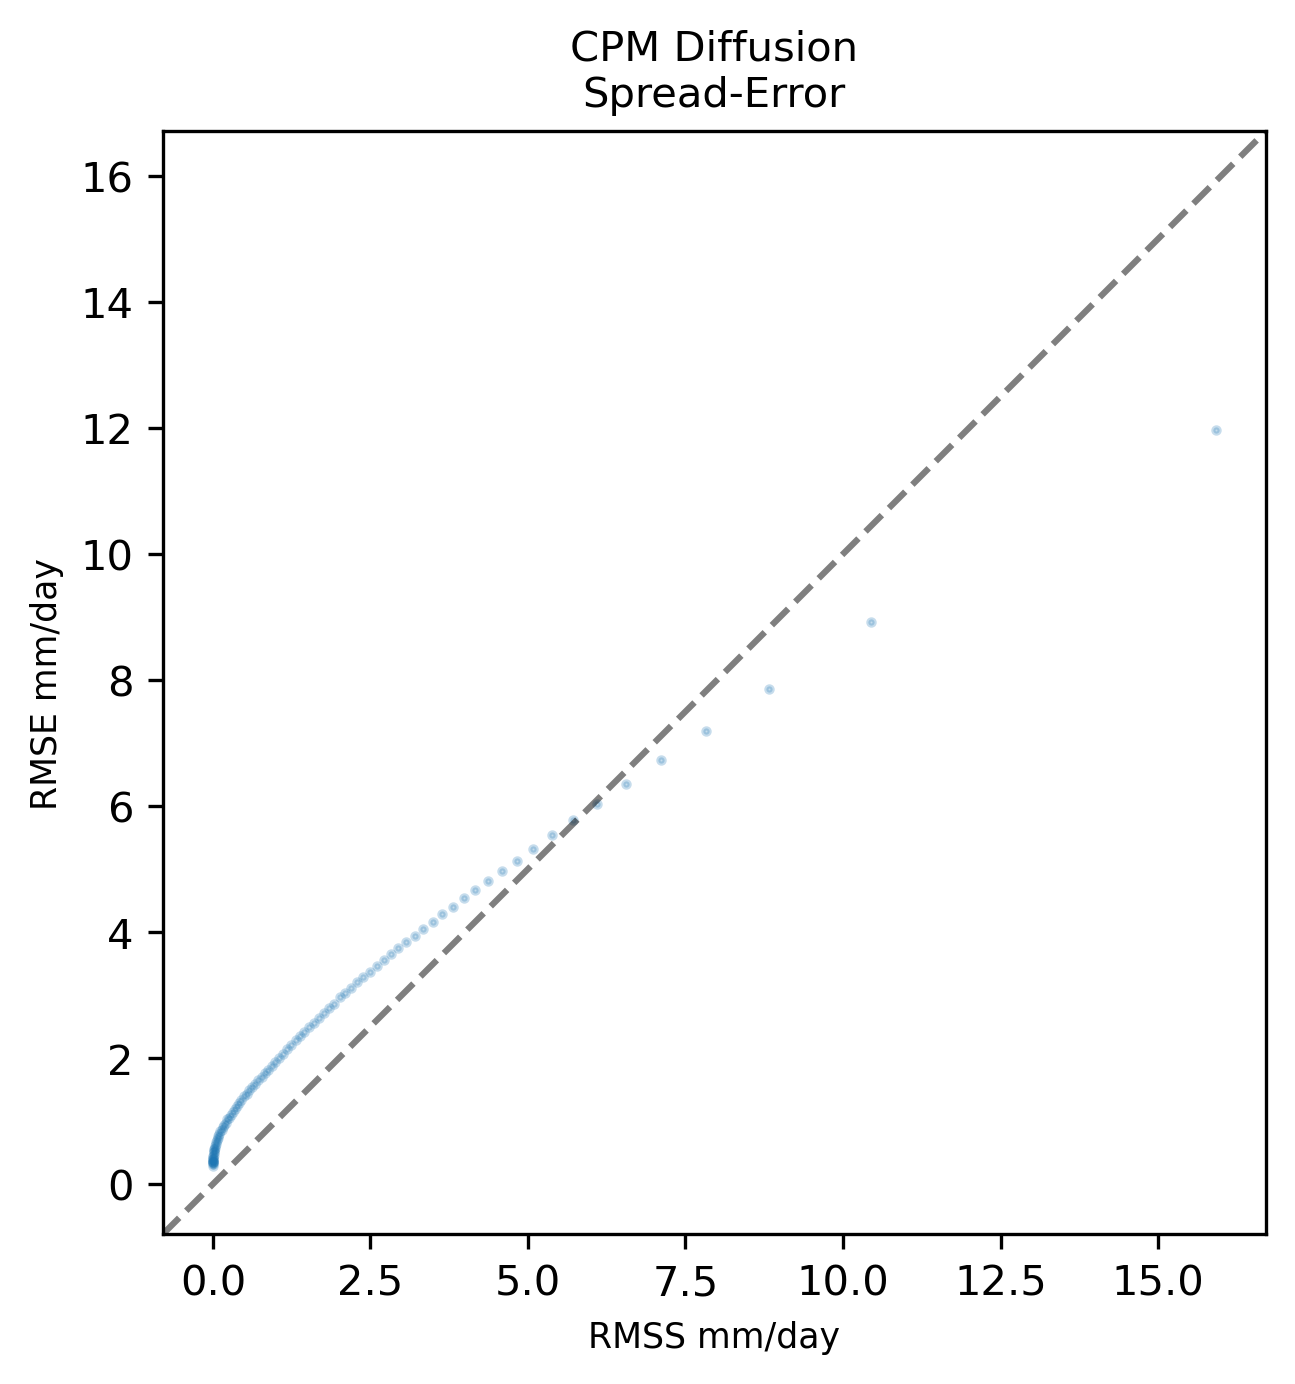

,serat,count,serat_low_spread,count_low_spread,serat_high_spread,count_high_spread,ssrel
model,,,,,,,
CPMGEM_cCPM,0.987,1.59e+08,0.76,1.44e+08,1.14,1.56e+07,0.703


In [ ]:
for var in eval_vars:
    mois = { model: mconfig for mconfigs in MODELS.values() for model, mconfig in mconfigs.items() if mconfig.get("UQ", True) and not mconfig["deterministic"] }
    ds = VAR_DAS[var].sel(model=list(mois.keys()))
    pred_da = ds[f"pred_{var}"]
    target_da = ds[f"target_{var}"]

    bins = se_bins(pred_da, target_da, nbins=100)

    spread_error_ds = pred_da.groupby("model").map(compute_rmss_rmse_bins, target_da=target_da, bins=bins)

    fig = plt.figure(layout='constrained', figsize=(4.5, 4.5))
    ax = fig.add_subplot()
    plot_spread_error(spread_error_ds, ax=ax, line_props=mois)

    plt.show()

    pretty_table(
        xr.merge([
            pred_da.groupby("model").map(serat, target_da=target_da),
            pred_da.groupby("model").map(serat, target_da=target_da, spread_range=(None,5)).rename({"serat": "serat_low_spread", "count": "count_low_spread"}),
            pred_da.groupby("model").map(serat, target_da=target_da, spread_range=(5,None)).rename({"serat": "serat_high_spread", "count": "count_high_spread"}),
            spread_error_ds["ssrel"],
        ]),
        round=3,
    )

## Rank Histograms

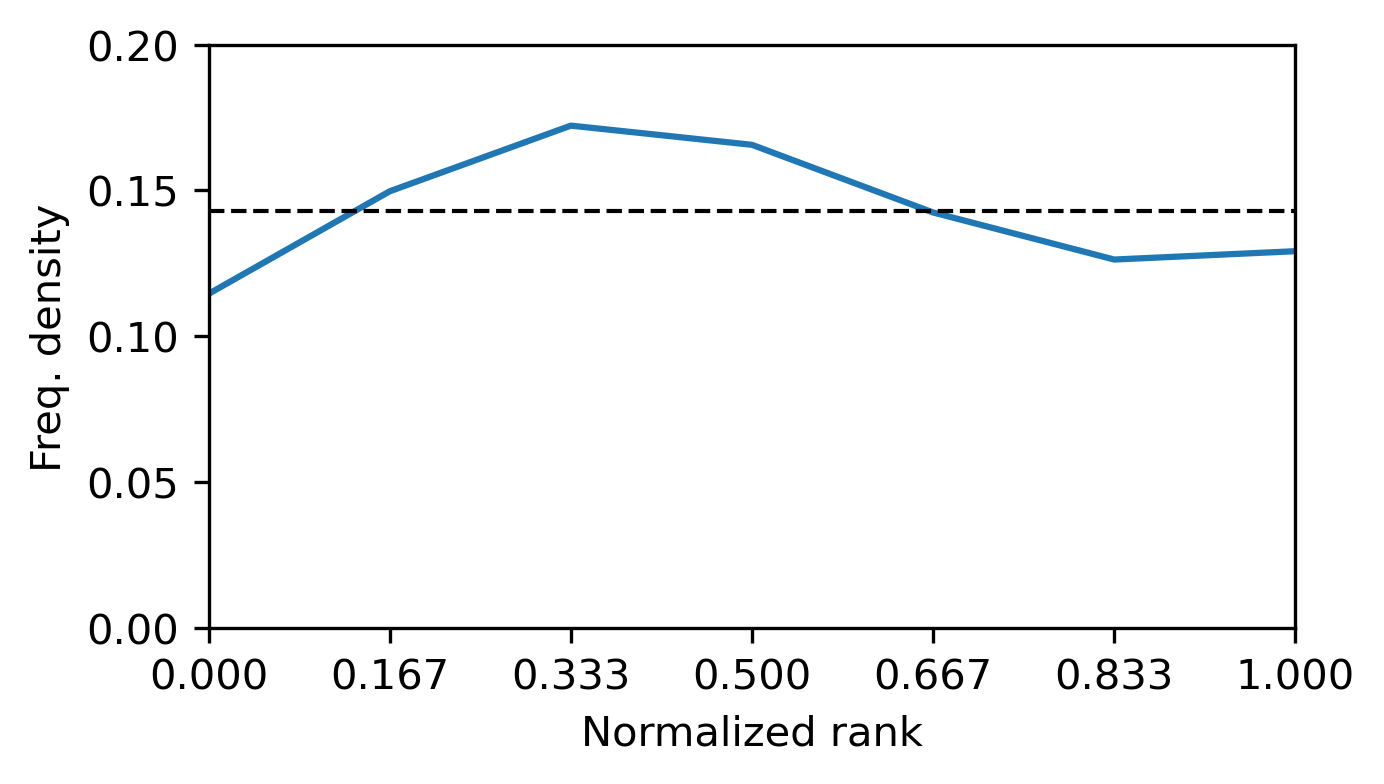

In [ ]:
for var in eval_vars:
    nsamples = len(PRED_DAS[var]["sample_id"])
    mois = { model: mconfig for mconfigs in MODELS.values() for model, mconfig in mconfigs.items() if mconfig.get("UQ", True) and not mconfig["deterministic"] }
    pred_da = PRED_DAS[var].sel(model=list(mois.keys())).assign_attrs({"long_name": "ML "+PRED_DAS[var].attrs['long_name']})
    ranks = (pred_da < CPM_DAS[var]).sum(dim="sample_id").rename("ranks")
    ranks_h = histogram(
        ranks,
        bins=np.linspace(-0.5, nsamples+0.5, nsamples+2),
        density=True,
        dim=["grid_longitude", "grid_latitude", "ensemble_member", "time"],
        block_size=None,
    ).rename("Freq. density")
    ranks_h["ranks_bin"] = ranks_h["ranks_bin"]/nsamples
    ranks_h = ranks_h.rename({"ranks_bin": f"Normalized rank"})

    fig = plt.figure(figsize=(4.5*len(mois), 2.5), layout="constrained")
    axd = fig.subplot_mosaic([mois.keys()])
    for model, model_ranks_h in ranks_h.groupby("model"):
        ax = axd[model]
        model_ranks_h.plot(ax=ax, c=mois[model]["color"])
        ax.xaxis.set_ticks(np.linspace(0, 1, nsamples+1))
        ax.axhline(1.0/(nsamples+1), linestyle="--", linewidth=1, color="k")
        ax.set_xlim(0,1)
        ax.set_ylim(0,1/(nsamples-1))
        ax.set_title(model)
        if len(mois) == 1:
            ax.set_title("")